# French to English translation (Fixed)

## Download dataset

In [1]:
!pip install -q sacremoses

import os
import csv
import time
import math
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, Subset
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 15.7 MB/s eta 0:00:00


In [2]:
HIDDEN_SIZE          = 256         # From 32 -> 256 (Major capacity boost)
INTERMEDIATE_SIZE    = 256 * 4     # 1024 (Standard Transformer ratio)
NUM_ATTENTION_HEADS  = 8           # From 4 -> 8 (Better feature extraction)
NUM_ENCODER_LAYERS   = 4           # From 3 -> 4 (Deeper understanding)
NUM_DECODER_LAYERS   = 4           # From 3 -> 4
MAX_SEQ_LENGTH       = 128         # Keeping this at 128 as discussed

HIDDEN_DROPOUT_PROB  = 0.1
BATCH_SIZE           = 32
LR                   = 3e-4          # FIX #4: lowered from 1e-3 → more stable
MAX_EPOCHS           = 10
MAX_ITERATIONS       = 5000           # NEW: cap steps per epoch (None = unlimited)
WARMUP_STEPS         = 400          # NEW: linear LR warmup steps

D_K    = HIDDEN_SIZE // NUM_ATTENTION_HEADS   # 8 — head dimension
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Using device: {device}  |  GPUs available: {n_gpus}")
for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Using device: cuda  |  GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
class TranslationDataset(Dataset):
    def __init__(self, csv_file, src_lang_col, tgt_lang_col,
                 model_name, max_token_len=32):
        self.csv_file      = csv_file
        self.tokenizer     = AutoTokenizer.from_pretrained(model_name)
        self.src_col       = src_lang_col
        self.tgt_col       = tgt_lang_col
        self.max_token_len = max_token_len

        index_filename = os.path.basename(csv_file) + ".offsets.npy"
        index_path     = os.path.join("/kaggle/working", index_filename)
        if os.path.exists(index_path):
            self.offsets = list(map(int, __import__("numpy").load(index_path)))
        else:
            self.offsets = self._build_offset_index(csv_file, index_path)

        with open(self.csv_file, "r", encoding="utf-8") as f:
            self.header = next(csv.reader(f))
        self.src_idx = self.header.index(src_lang_col)
        self.tgt_idx = self.header.index(tgt_lang_col)

    @staticmethod
    def _build_offset_index(csv_file, index_path):
        import numpy as np
        offsets = []
        with open(csv_file, "rb") as f:
            f.readline()
            while True:
                pos = f.tell()
                line = f.readline()
                if not line:
                    break
                offsets.append(pos)
        np.save(index_path, offsets)
        print(f"Offset index saved → {index_path}  ({len(offsets):,} rows)")
        return offsets

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, index):
        with open(self.csv_file, "r", encoding="utf-8") as f:
            f.seek(self.offsets[index])
            row = next(csv.reader(f))

        source_text = row[self.src_idx]
        target_text = row[self.tgt_idx]

        def encode(text):
            return self.tokenizer(
                text,
                max_length=self.max_token_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )

        src_enc = encode(source_text)
        tgt_enc = encode(target_text)

        labels = tgt_enc["input_ids"].flatten().clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "source_ids":  src_enc["input_ids"].flatten(),
            "source_mask": src_enc["attention_mask"].flatten(),
            "target_ids":  labels,
            "target_mask": tgt_enc["attention_mask"].flatten(),
        }

In [4]:
# FIX #2: scale embeddings by 1/sqrt(d_model) so logits don't explode
class TransformerEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        # FIX #2: randn * (d_model**-0.5) — prevents logit explosion via weight tying
        self.E = nn.Parameter(torch.randn(vocab_size, d_model) * (d_model ** -0.5))
        self.P = nn.Parameter(torch.randn(max_len, d_model)    * (d_model ** -0.5))

    def forward(self, tokens):
        n = tokens.shape[1]
        token_embs = self.E[tokens]   # (B, n, d)
        pos_embs   = self.P[:n, :]    # (n, d)
        return token_embs + pos_embs  # (B, n, d)

In [5]:
class SelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W_q         = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_k         = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_v         = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_o         = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        # FIX #3: attention dropout
        # self.attn_drop   = nn.Dropout(HIDDEN_DROPOUT_PROB)
        self.attn_weights = None

    def forward(self, x, mask=None):
        B = x.size(0)

        def project_and_split(W):
            return W(x).view(B, -1, NUM_ATTENTION_HEADS, D_K).transpose(1, 2)

        Q = project_and_split(self.W_q)
        K = project_and_split(self.W_k)
        V = project_and_split(self.W_v)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(D_K)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        # FIX #1: replace NaN (from all-inf rows) with 0 before multiplying V
        attn = torch.nan_to_num(attn, nan=0.0)
        # attn = self.attn_drop(attn)          # FIX #3: dropout on attention weights
        self.attn_weights = attn.detach()

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, HIDDEN_SIZE)
        return self.W_o(out)

In [6]:
class CrossAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W_q          = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_k          = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_v          = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        self.W_o          = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
        # FIX #3: attention dropout
        # self.attn_drop    = nn.Dropout(HIDDEN_DROPOUT_PROB)
        self.attn_weights = None

    def forward(self, x, enc_out, mask=None):
        B = x.size(0)

        def split(W, src):
            return W(src).view(B, -1, NUM_ATTENTION_HEADS, D_K).transpose(1, 2)

        Q = split(self.W_q, x)
        K = split(self.W_k, enc_out)
        V = split(self.W_v, enc_out)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(D_K)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        # FIX #1: replace NaN (from all-inf rows) with 0 before multiplying V
        attn = torch.nan_to_num(attn, nan=0.0)
        # attn = self.attn_drop(attn)          # FIX #3: dropout on attention weights
        self.attn_weights = attn.detach()

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, HIDDEN_SIZE)
        return self.W_o(out)

In [7]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1     = nn.Linear(HIDDEN_SIZE, INTERMEDIATE_SIZE)
        self.fc2     = nn.Linear(INTERMEDIATE_SIZE, HIDDEN_SIZE)
        # FIX #3: dropout was defined globally but never used — added here
        self.dropout = nn.Dropout(HIDDEN_DROPOUT_PROB)

    def forward(self, x):
        return self.dropout(self.fc2(F.relu(self.fc1(x))))

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = SelfAttention()
        self.ff        = FeedForward()
        self.norm1     = nn.LayerNorm(HIDDEN_SIZE)
        self.norm2     = nn.LayerNorm(HIDDEN_SIZE)

    def forward(self, x, src_mask=None):
        x = self.norm1(x + self.self_attn(x, src_mask))
        x = self.norm2(x + self.ff(x))
        return x


class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn  = SelfAttention()
        self.cross_attn = CrossAttention()
        self.ff         = FeedForward()
        self.norm1      = nn.LayerNorm(HIDDEN_SIZE)
        self.norm2      = nn.LayerNorm(HIDDEN_SIZE)
        self.norm3      = nn.LayerNorm(HIDDEN_SIZE)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.self_attn(x, tgt_mask))
        x = self.norm2(x + self.cross_attn(x, enc_out, src_mask))
        x = self.norm3(x + self.ff(x))
        return x

In [9]:
class Encoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = TransformerEmbedding(vocab_size, HIDDEN_SIZE, MAX_SEQ_LENGTH)
        self.layers    = nn.ModuleList([EncoderLayer() for _ in range(NUM_ENCODER_LAYERS)])

    def forward(self, src, src_mask=None):
        x = self.embedding(src)
        for layer in self.layers:
            x = layer(x, src_mask)
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = TransformerEmbedding(vocab_size, HIDDEN_SIZE, MAX_SEQ_LENGTH)
        self.layers    = nn.ModuleList([DecoderLayer() for _ in range(NUM_DECODER_LAYERS)])

    def forward(self, tgt, enc_out, src_mask=None, tgt_mask=None):
        x = self.embedding(tgt)
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return x @ self.embedding.E.T   # weight-tied projection → (B, n, vocab_size)

In [10]:
class Transformer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = Encoder(vocab_size)
        self.decoder = Decoder(vocab_size)

    def make_src_mask(self, src):
        return (src != 0).unsqueeze(1).unsqueeze(2)   # (B, 1, 1, n)

    def make_tgt_mask(self, tgt):
        n = tgt.size(1)
        pad_mask    = (tgt != 0).unsqueeze(1).unsqueeze(2)                      # (B, 1, 1, n)
        causal_mask = torch.tril(torch.ones(n, n, device=tgt.device)).bool()    # (n, n)
        return pad_mask & causal_mask                                            # (B, 1, n, n)

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out  = self.encoder(src, src_mask)
        logits   = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        return logits   # (B, n, vocab_size)

In [11]:
def unwrap(model):
    """Get the underlying Transformer whether wrapped in DataParallel or not."""
    return model.module if isinstance(model, nn.DataParallel) else model


def save_checkpoint(model, optimizer, scheduler, epoch, loss,
                    path="/kaggle/working/checkpoint.pt"):
    torch.save({
        "epoch":     epoch,
        "model":     unwrap(model).state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "loss":      loss,
    }, path)
    print(f"Checkpoint saved → {path}  (epoch {epoch}, loss {loss:.4f})")


from collections import OrderedDict

def load_checkpoint(model, optimizer, scheduler, path="/kaggle/working/checkpoint.pt"):
    if not os.path.exists(path):
        print("No checkpoint found, starting fresh.")
        return 0, float("inf")

    ckpt = torch.load(path, map_location=device)

    new_state_dict = OrderedDict()
    for k, v in ckpt["model"].items():
        new_state_dict[k.replace("module.", "")] = v

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(new_state_dict)

    optimizer.load_state_dict(ckpt["optimizer"])
    if "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])

    loss_val = ckpt["loss"] if isinstance(ckpt["loss"], float) else float(ckpt["loss"])
    print(f"Checkpoint loaded ← {path}  (epoch {ckpt['epoch']}, loss {loss_val:.4f})")
    return ckpt["epoch"], loss_val

In [12]:
log_interval = 5

def train(model, loader, optimizer, scheduler, epoch,
          best_interval_loss=float("inf"),
          max_iterations=MAX_ITERATIONS):   # NEW: pass None for unlimited
    model.train()
    total_loss, total_tokens = 0.0, 0
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}")
    for step, batch in enumerate(pbar):

        # NEW: stop after max_iterations steps if a limit is set
        if max_iterations is not None and step >= max_iterations:
            print(f"  Reached MAX_ITERATIONS={max_iterations}, stopping epoch early.")
            break

        src = batch["source_ids"].to(device)
        tgt = batch["target_ids"].to(device)

        # Teacher forcing — shift targets
        tgt_input  = tgt[:, :-1].clone()
        tgt_input[tgt_input == -100] = 0   # replace label-ignore index with pad id
        tgt_target = tgt[:, 1:]

        logits = model(src, tgt_input)

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            tgt_target.reshape(-1),
            ignore_index=-100
        )

        # NEW: guard against NaN loss before stepping (safety net)
        if not torch.isfinite(loss):
            print(f"  WARNING: non-finite loss ({loss.item()}) at step {step} — skipping batch.")
            optimizer.zero_grad()
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()   # FIX #4: warmup step after every optimizer step

        n_tokens      = (tgt_target != -100).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens
        running_loss += loss.item()

        if (step + 1) % log_interval == 0:
            interval_avg_loss = running_loss / log_interval

            if interval_avg_loss < best_interval_loss:
                best_interval_loss = interval_avg_loss
                torch.save(model.state_dict(), "/kaggle/working/best_model.pt")
                checkpoint_msg = " (Saved!)"
            else:
                checkpoint_msg = ""

            current_lr = scheduler.get_last_lr()[0]
            pbar.set_postfix({
                "step": step + 1,
                "loss": f"{interval_avg_loss:.4f}",
                "best": f"{best_interval_loss:.4f}{checkpoint_msg}",
                "lr":   f"{current_lr:.2e}",
            })
            running_loss = 0.0

    if total_tokens == 0:
        return float("inf"), best_interval_loss

    avg_loss = total_loss / total_tokens
    print(f"Epoch {epoch:>2} | loss {avg_loss:.4f} | ppl {math.exp(min(avg_loss, 20)):.2f}")
    return avg_loss, best_interval_loss


def run_training(model, loader, resume=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # FIX #4: linear warmup for WARMUP_STEPS steps, then constant LR
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1e-2,       # start at LR * 0.01
        end_factor=1.0,
        total_iters=WARMUP_STEPS
    )

    start_epoch, _ = (
        load_checkpoint(model, optimizer, scheduler)
        if resume else (0, float("inf"))
    )

    best_interval_loss = float("inf")
    for epoch in range(start_epoch + 1, MAX_EPOCHS + 1):
        t0 = time.time()
        avg_loss, best_interval_loss = train(
            model, loader, optimizer, scheduler, epoch,
            best_interval_loss=best_interval_loss
        )
        print(f"         time {time.time() - t0:.1f}s")
        save_checkpoint(model, optimizer, scheduler, epoch, avg_loss)

In [13]:
def beam_search(model, src_ids, tokenizer, beam_size=4, max_len=MAX_SEQ_LENGTH):
    model.eval()
    with torch.no_grad():
        src_mask = unwrap(model).make_src_mask(src_ids)
        enc_out  = unwrap(model).encoder(src_ids, src_mask)

        bos_id = tokenizer.pad_token_id
        eos_id = tokenizer.eos_token_id

        beams     = [(0.0, [bos_id])]
        completed = []

        for _ in range(max_len):
            candidates = []
            for log_prob, tokens in beams:
                if tokens[-1] == eos_id:
                    completed.append((log_prob, tokens))
                    continue
                tgt      = torch.tensor([tokens], device=device)
                tgt_mask = unwrap(model).make_tgt_mask(tgt)
                logits   = unwrap(model).decoder(tgt, enc_out, src_mask, tgt_mask)
                log_probs = F.log_softmax(logits[0, -1], dim=-1)
                top_lp, top_ids = log_probs.topk(beam_size)
                for lp, idx in zip(top_lp.tolist(), top_ids.tolist()):
                    candidates.append((log_prob + lp, tokens + [idx]))

            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_size]

            if all(t[-1] == eos_id for _, t in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams

        completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        return completed[0][1]


def compute_bleu(model, dataset, tokenizer, n_samples=500, beam_size=4):
    references, hypotheses = [], []
    smoother = SmoothingFunction().method1

    for i in range(min(n_samples, len(dataset))):
        sample   = dataset[i]
        src      = sample["source_ids"].unsqueeze(0).to(device)
        pred_ids = beam_search(model, src, tokenizer, beam_size)
        pred_ids = [t for t in pred_ids
                    if t not in (tokenizer.pad_token_id, tokenizer.eos_token_id)]

        ref_ids = sample["target_ids"]
        ref_ids = [t.item() for t in ref_ids
                   if t.item() not in (-100, tokenizer.eos_token_id)]

        hypotheses.append(tokenizer.convert_ids_to_tokens(pred_ids))
        references.append([tokenizer.convert_ids_to_tokens(ref_ids)])

    score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    print(f"BLEU score ({n_samples} samples): {score:.4f}")
    return score


def visualize_attention(model, dataset, tokenizer, sample_idx=0):
    model.eval()
    sample  = dataset[sample_idx]
    src_ids = sample["source_ids"].unsqueeze(0).to(device)
    tgt_ids = sample["target_ids"].unsqueeze(0)
    tgt_ids = tgt_ids.masked_fill(tgt_ids == -100, 0).to(device)

    with torch.no_grad():
        unwrap(model)(src_ids, tgt_ids)

    src_tokens = tokenizer.convert_ids_to_tokens(src_ids[0].tolist())
    tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids[0].tolist())

    src_len = next((i for i, t in enumerate(src_tokens) if t == tokenizer.pad_token), len(src_tokens))
    tgt_len = next((i for i, t in enumerate(tgt_tokens) if t == tokenizer.pad_token), len(tgt_tokens))
    src_tokens = src_tokens[:src_len]
    tgt_tokens = tgt_tokens[:tgt_len]

    fig, axes = plt.subplots(2, NUM_ATTENTION_HEADS,
                             figsize=(4 * NUM_ATTENTION_HEADS, 8))
    fig.suptitle("Attention weights — last encoder layer (top) · last decoder cross-attn (bottom)")

    enc_attn = unwrap(model).encoder.layers[-1].self_attn.attn_weights
    for h in range(NUM_ATTENTION_HEADS):
        w  = enc_attn[0, h, :src_len, :src_len].cpu().numpy()
        ax = axes[0, h]
        ax.imshow(w, cmap="Blues")
        ax.set_xticks(range(src_len)); ax.set_xticklabels(src_tokens, rotation=90, fontsize=7)
        ax.set_yticks(range(src_len)); ax.set_yticklabels(src_tokens, fontsize=7)
        ax.set_title(f"Enc head {h+1}", fontsize=9)

    dec_attn = unwrap(model).decoder.layers[-1].cross_attn.attn_weights
    for h in range(NUM_ATTENTION_HEADS):
        w  = dec_attn[0, h, :tgt_len, :src_len].cpu().numpy()
        ax = axes[1, h]
        ax.imshow(w, cmap="Oranges")
        ax.set_xticks(range(src_len)); ax.set_xticklabels(src_tokens, rotation=90, fontsize=7)
        ax.set_yticks(range(tgt_len)); ax.set_yticklabels(tgt_tokens, fontsize=7)
        ax.set_title(f"Cross head {h+1}", fontsize=9)

    plt.tight_layout()
    plt.savefig("/kaggle/working/attention.png", dpi=150)
    plt.show()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

  Reached MAX_ITERATIONS=5000, stopping epoch early.
Epoch  8 | loss 1.6661 | ppl 5.29
         time 2542.5s
Checkpoint saved → /kaggle/working/checkpoint.pt  (epoch 8, loss 1.6661)


Epoch 9:   0%|          | 0/351881 [00:02<?, ?it/s]

  Reached MAX_ITERATIONS=5000, stopping epoch early.
Epoch  9 | loss 1.6305 | ppl 5.11
         time 2540.6s
Checkpoint saved → /kaggle/working/checkpoint.pt  (epoch 9, loss 1.6305)


Epoch 10:   0%|          | 0/351881 [00:02<?, ?it/s]

  Reached MAX_ITERATIONS=5000, stopping epoch early.
Epoch 10 | loss 1.6050 | ppl 4.98
         time 2541.2s
Checkpoint saved → /kaggle/working/checkpoint.pt  (epoch 10, loss 1.6050)
BLEU score (100 samples): 0.2381


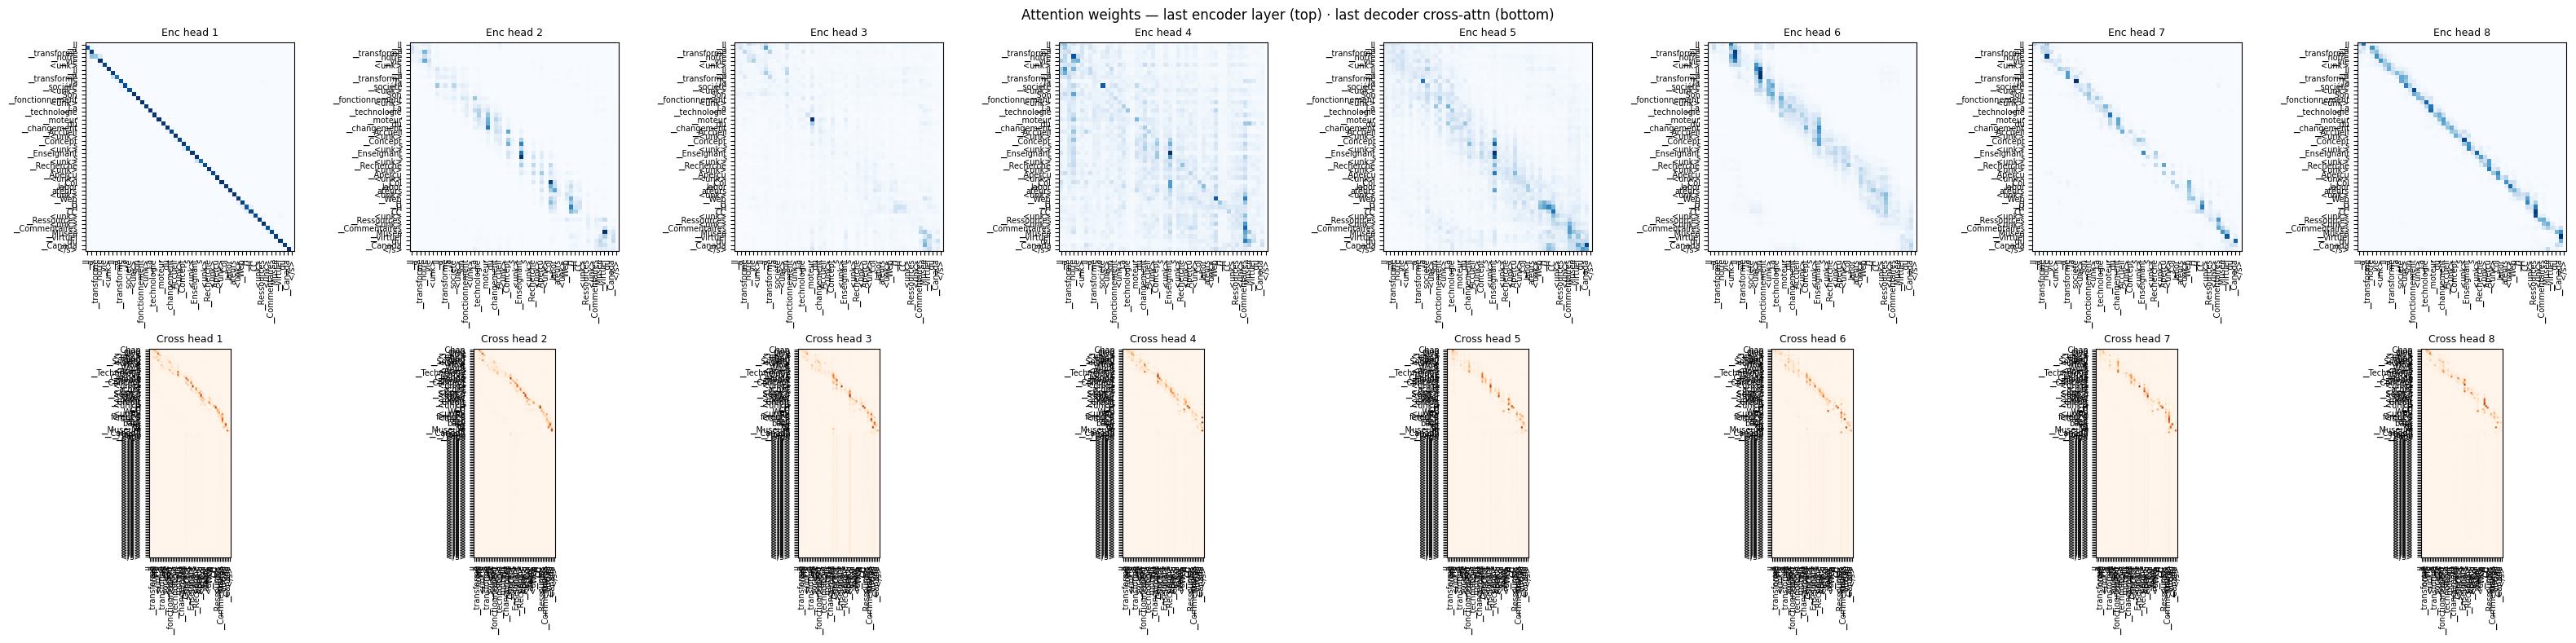

In [14]:
# ── Putting it all together ───────────────────────────────────────────────────

csv_path = "/kaggle/input/datasets/dhruvildave/en-fr-translation-dataset/en-fr.csv"

full_dataset = TranslationDataset(
    csv_path, "fr", "en",
    "Helsinki-NLP/opus-mt-fr-en",
    max_token_len=MAX_SEQ_LENGTH
)

subset_indices = list(range(len(full_dataset)))
subset_dataset = Subset(full_dataset, subset_indices)

loader    = DataLoader(
    subset_dataset,
    batch_size=BATCH_SIZE * max(n_gpus, 1),
    shuffle=True,
    num_workers=2 * max(n_gpus, 1),
    pin_memory=True
)
tokenizer = full_dataset.tokenizer

model = Transformer(vocab_size=tokenizer.vocab_size).to(device)
if n_gpus > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel enabled across {n_gpus} GPUs")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"MAX_ITERATIONS per epoch: {MAX_ITERATIONS}")

run_training(model, loader)

bleu = compute_bleu(model, full_dataset, tokenizer, n_samples=100, beam_size=4)

visualize_attention(model, full_dataset, tokenizer, sample_idx=0)

In [15]:
def translate_sentence(sentence, model, tokenizer, device, beam_size=4):
    model.eval()
    
    # 1. Tokenize the French sentence
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128)
    src_ids = inputs["input_ids"].to(device)
    
    # 2. Generate using your existing beam_search function
    with torch.no_grad():
        pred_ids = beam_search(model, src_ids, tokenizer, beam_size=beam_size)
    
    # 3. Decode back to English
    # We skip special tokens like <pad>, <s>, </s>
    translation = tokenizer.decode(pred_ids, skip_special_tokens=True)
    
    print(f"Source (FR): {sentence}")
    print(f"Output (EN): {translation}")
    print("-" * 30)
    return translation

# --- TEST AREA ---
test_sentences = [
    "C'est un petit projet pour mon CV.",
    "Le chat est sur le tapis.",
    "Je travaille sur Kaggle avec deux GPU.",
    "Bonjour, comment allez-vous aujourd'hui ?"
]

print("--- MODEL INFERENCE TEST ---")
for sent in test_sentences:
    translate_sentence(sent, model, tokenizer, device)

--- MODEL INFERENCE TEST ---
Source (FR): C'est un petit projet pour mon CV.
Output (EN): ZZZZZZZZZFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFTFT
------------------------------
Source (FR): Le chat est sur le tapis.
Output (EN): ZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZ
------------------------------
Source (FR): Je travaille sur Kaggle avec deux GPU.
Output (EN): ZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZ
------------------------------
Source (FR): Bonjour, comment allez-vous aujourd'hui ?
Output (EN): ZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZ